In [2]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset
from tensorflow import keras
import tensorflow_probability as tfp

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame

from scipy.stats.stats import pearsonr
from geopy.distance import geodesic

from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from collections import defaultdict
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from geopy.distance import geodesic

from mapie.regression import MapieQuantileRegressor
from scipy.stats import randint, uniform

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

from sklearn.linear_model import Lasso
from scipy.optimize import linprog
from scipy.optimize import minimize

import pyreadr
import random

import seaborn as sns
import contextily as ctx
import tensorflow as tf

import keras_tuner as kt

2025-01-17 02:10:03.685559: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/var/folders/19/b_t4kk7x6cs9yr5g7mhxmk1c0000gp/T/ipykernel_38433/4011320821.py:34: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [4]:
housing_df = pd.read_csv("/Users/shrey/Downloads/Soil_Land_Crop/datasets/Standard_regression/BostonHousing/BostonHousing.csv")

In [5]:
housing_df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

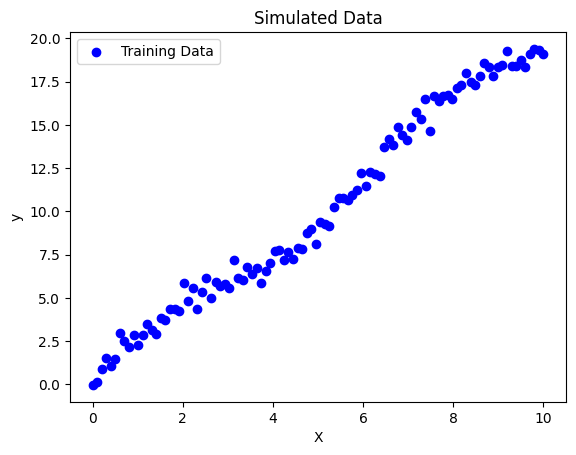

In [8]:
# Generate simulated data

np.random.seed(42)  # For reproducibility
X = np.linspace(0, 10, 100).reshape(-1, 1)  # Input features
y = 2.0 * X.flatten() + np.sin(X.flatten()) + np.random.normal(0, 0.5, size=X.shape[0])  # Output values

# Add some noise for realism
y += np.random.normal(0, 0.2, size=y.shape)

# Plot the data
plt.scatter(X, y, color="blue", label="Training Data")
plt.title("Simulated Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [9]:
# Define the Gaussian Process model with a kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.5**2)

# Fit the model to the data
gp.fit(X, y)

# Predict on new data
X_pred = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred, y_std = gp.predict(X_pred, return_std=True)


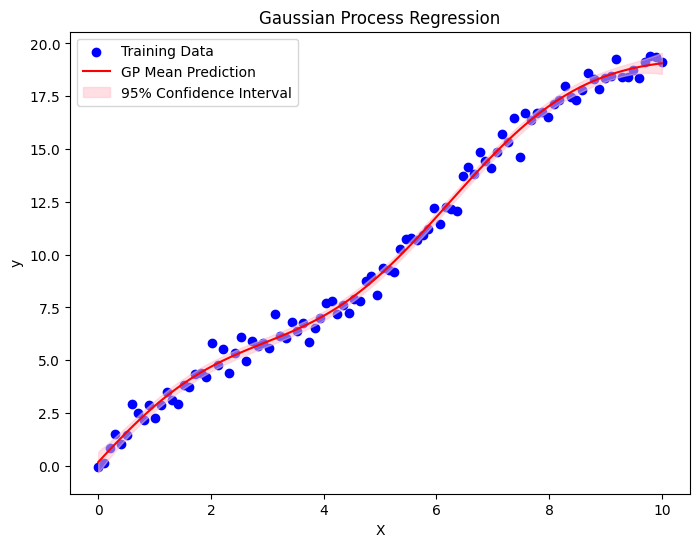

In [10]:
# Plot predictions with confidence intervals
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="blue", label="Training Data")
plt.plot(X_pred, y_pred, color="red", label="GP Mean Prediction")
plt.fill_between(
    X_pred.flatten(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    color="pink",
    alpha=0.5,
    label="95% Confidence Interval"
)
plt.title("Gaussian Process Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [6]:
# Features and target
X = housing_df.drop(columns=['medv'])
y = housing_df['medv']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features for better Gaussian Process performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# Define the kernel for the Gaussian Process
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# Initialize the Gaussian Process Regressor
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.5**2)

# Fit the model on the training data
gp.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred, y_std = gp.predict(X_test_scaled, return_std=True)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 18.67
R^2 Score: 0.75


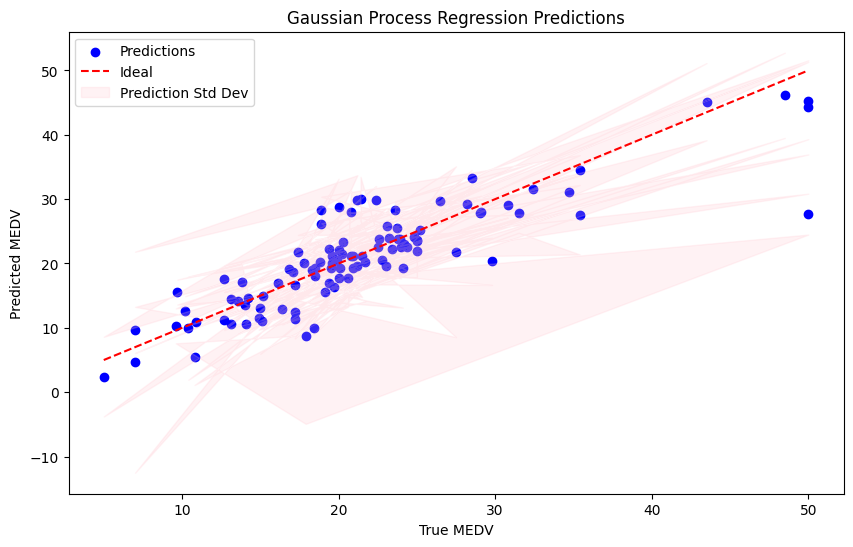

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color="blue", label="Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Ideal")
plt.fill_between(y_test, y_pred - y_std, y_pred + y_std, color="pink", alpha=0.2, label="Prediction Std Dev")
plt.title("Gaussian Process Regression Predictions")
plt.xlabel("True MEDV")
plt.ylabel("Predicted MEDV")
plt.legend()
plt.show()

In [ ]:
import xgboost as xgb

# Initialize the XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=100,    # Number of trees
    learning_rate=0.1,   # Step size shrinkage
    max_depth=5,         # Maximum tree depth
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest regressor
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees
    max_depth=10,      # Maximum depth of trees
    random_state=42    # For reproducibility
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 7.76
R^2 Score: 0.89
